# Buscar Scores vs Cell Count Scatter Plot (Healthy TGFRi)

This notebook plots the relationship between BUSCAR scores and cell counts for healthy TGFRi replicates.

`geom_smooth()` using formula = 'y ~ x'


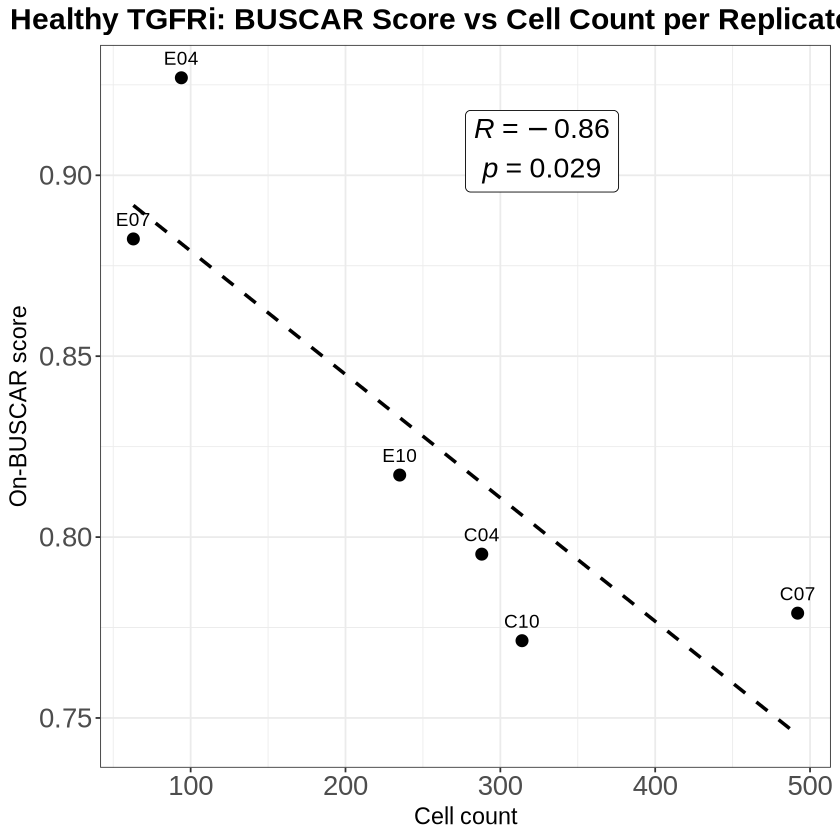

In [7]:
library(ggplot2)
library(dplyr)
library(ggpubr)


`geom_smooth()` using formula = 'y ~ x'


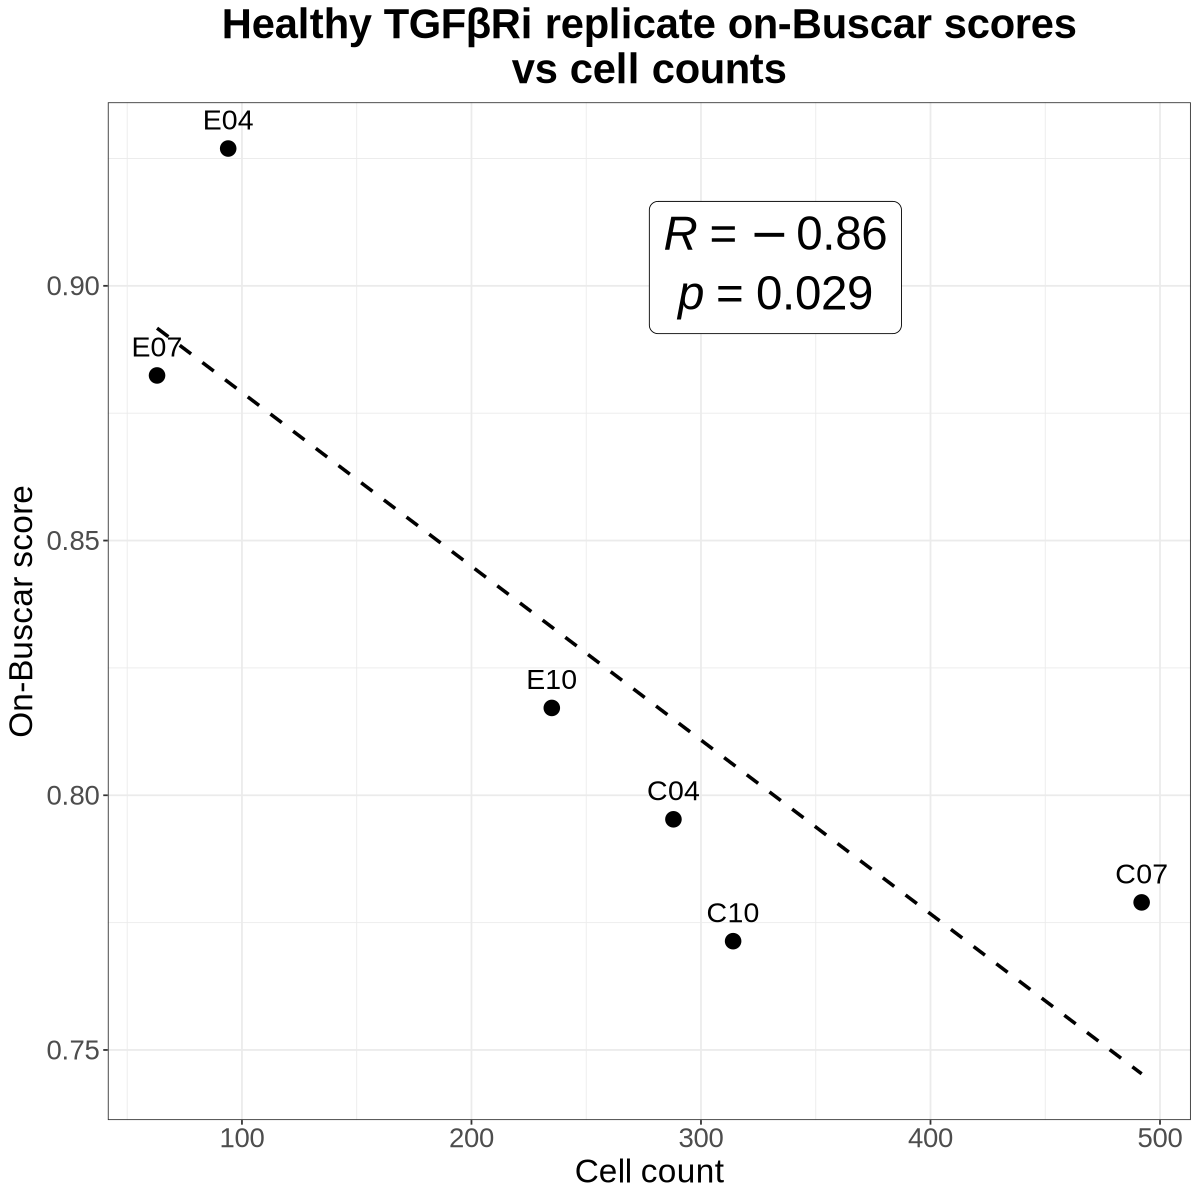

In [29]:
width <- 10
height <- 10
options(repr.plot.width = width, repr.plot.height = height)
# Load data
scores_path <- "../results/phenotypic_scores/cellpainting_cardiac_fibrosis_buscar_scores_replicates.csv"
df <- read.csv(scores_path)

# Filter for healthy TGFRi
df_filtered <- df %>%
  filter(treatment == "healthy-TGFRi")

# Use on_buscar_scores column
# Create plot
p <- ggplot(df_filtered, aes(x = cell_counts, y = on_buscar_scores)) +
  geom_point(size = 4) +
  geom_text(aes(label = well), vjust = -1, size =6) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  stat_cor(
    method = "pearson", 
    label.x.npc = "center", 
    label.y.npc = "top",
    size = 10,
    label.sep = "\n",
    p.accuracy = 0.001,
    r.accuracy = 0.01,
    geom = "label",
    fill = "white"
  ) +
  labs(
    title = "Healthy TGFβRi replicate on-Buscar scores\nvs cell counts",
    x = "Cell count",
    y = "On-Buscar score"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = rel(1.5)),
    legend.position = ""
  )

p

`geom_smooth()` using formula = 'y ~ x'


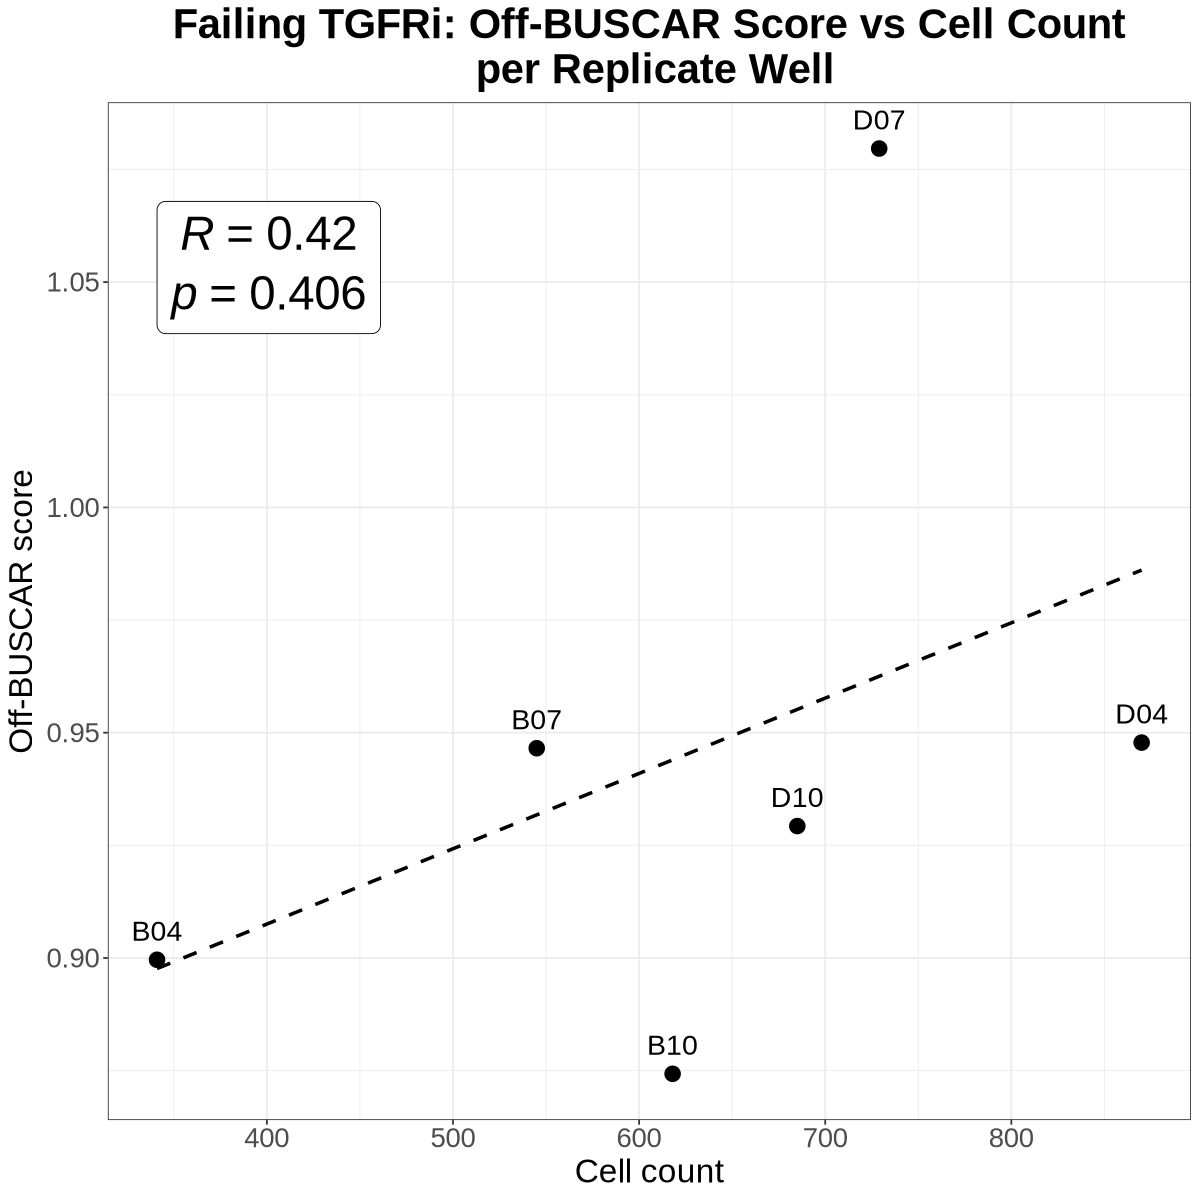

In [32]:
# Filter for failing TGFRi
df_failing <- df %>%
  filter(treatment == "failing-TGFRi")

# Create plot for Off-BUSCAR score
p_off <- ggplot(df_failing, aes(x = cell_counts, y = on_buscar_scores)) +
  geom_point(size = 4) +
  geom_text(aes(label = well), vjust = -1, size = 6) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  stat_cor(
    method = "pearson", 
    label.x.npc = "left", 
    label.y.npc = "top",
    size = 10,
    label.sep = "\n",
    p.accuracy = 0.001,
    r.accuracy = 0.01,
    geom = "label",
    fill = "white"
  ) +
  labs(
    title = "Failing TGFRi: Off-BUSCAR Score vs Cell Count\n per Replicate Well",
    x = "Cell count",
    y = "Off-BUSCAR score"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = rel(1.5)),
    legend.position = "none"
  )

p_off